# 배송일 하루당 리뷰 점수 평균

**목적**: "배송이 X일 걸린 주문의 평균 만족도는?" 을 정량화.
배송 시간이 길어질수록 만족도가 떨어진다는 가설을 검증하고, **몇 일이 임계점**인지 찾는다.

**입력**: `funnel_df.csv`
**분석 단위**:
- `t_total_d` (주문→배송 완료, 전체 리드타임) — 메인
- `t_carrier_d` (판매자 구간), `t_delivery_d` (택배사 구간) — 비교용
- 정수 일(day) 단위로 floor 해서 그룹핑 → 그룹별 `review_score` 평균

**대상**: `is_valid_funnel == True` AND `review_score` 존재 (≈ 94k건 예상)

**핵심 질문**:
1. 배송이 하루 늘어날 때마다 평균 리뷰가 얼마나 떨어지는가?
2. 만족도가 급락하는 변곡점(threshold)이 있는가? → A/B 테스트 KPI 기준선
3. 어느 단계(②판매자 vs ③택배사)의 시간이 만족도에 더 큰 영향을 주는가?

In [1]:
import platform
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ─── 시각화 스타일 통일 (funnel_eda.ipynb 와 동일 패턴) ─────────────────────
sns.set_theme(style="whitegrid", palette="Set2")

plt.rcParams.update({
    "figure.figsize": (12, 5),
    "axes.titlesize": 14,
    "axes.titleweight": "bold",
    "axes.labelsize": 11,
    "axes.titlepad": 12,
    "grid.alpha": 0.3,
})

# 한글 폰트 (seaborn 뒤에 설정 — sns.set_theme 가 font.family 를 덮어쓰기 때문)
if platform.system() == "Windows":
    plt.rcParams["font.family"] = "Malgun Gothic"
    plt.rcParams["font.sans-serif"] = ["Malgun Gothic", "DejaVu Sans"]
elif platform.system() == "Darwin":
    plt.rcParams["font.family"] = "AppleGothic"
    plt.rcParams["font.sans-serif"] = ["AppleGothic", "DejaVu Sans"]
else:
    plt.rcParams["font.family"] = "NanumGothic"
    plt.rcParams["font.sans-serif"] = ["NanumGothic", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False

# 단계별 색상 — funnel_eda 와 동일
STAGE_COLORS = {
    "t_carrier_d":  "#F4A460",   # 주황 — 판매자
    "t_delivery_d": "#E74C3C",   # 빨강 — 택배사
    "t_total_d":    "#5B9BD5",   # 파랑 — 전체
}
STAGE_LABELS = {
    "t_carrier_d":  "② 승인→택배사 (판매자)",
    "t_delivery_d": "③ 택배사→고객 (택배사)",
    "t_total_d":    "전체 리드타임 (주문→배송)",
}

# ─── 데이터 로드 + 분석 대상 필터 ────────────────────────────────────────────
DATE_COLS = [
    "order_purchase_timestamp", "order_approved_at",
    "order_delivered_carrier_date", "order_delivered_customer_date",
    "order_estimated_delivery_date",
]
df = pd.read_csv("funnel_df.csv", parse_dates=DATE_COLS)

# 유효 주문 + 리뷰 점수 존재
data = df[df["is_valid_funnel"] & df["review_score"].notna()].copy()

print(f"전체 주문      : {len(df):,}")
print(f"유효 + 리뷰 존재: {len(data):,}  ({len(data)/len(df)*100:.2f}%)")
print(f"리뷰 점수 분포 : {data['review_score'].value_counts().sort_index().to_dict()}")
print(f"전체 평균 리뷰 : {data['review_score'].mean():.3f}")


전체 주문      : 99,441
유효 + 리뷰 존재: 94,449  (94.98%)
리뷰 점수 분포 : {1.0: 9241, 2.0: 2883, 3.0: 7821, 4.0: 18619, 5.0: 55885}
전체 평균 리뷰 : 4.154


## 1. 일자(day) 단위로 floor → 그룹별 평균 계산

소수점 일수(`t_total_d` 등)는 `np.floor` 로 정수 일수 버킷으로 만든다.
- `floor` 사용 이유: "N일 ~ (N+1)일 사이에 걸린 주문" 이라는 자연스러운 의미 (반올림은 경계가 어색).
- 표본이 너무 적은 day(주문 < 30) 는 그래프에서 강조 안 함 (노이즈).

In [ ]:
# 정수 일수 버킷 컬럼 추가
for col in ["t_total_d", "t_carrier_d", "t_delivery_d"]:
    data[col + "_day"] = np.floor(data[col]).astype(int)

def review_by_day(d, day_col, min_n=30):
    """day_col 단위로 review_score 평균/표본수/표준오차 집계."""
    g = d.groupby(day_col)["review_score"].agg(["mean", "count", "std"]).reset_index()
    g.columns = ["day", "avg_review", "n", "std"]
    g["se"] = g["std"] / np.sqrt(g["n"])     # 표준오차 → 신뢰구간용
    g["is_robust"] = g["n"] >= min_n         # 표본 충분한 day
    return g

# 메인: 전체 리드타임 기준
review_total = review_by_day(data, "t_total_d_day")
print("전체 리드타임 — 첫 15일:")
print(review_total.head(15).round(3))
print(f"\n전체 day 범위: {review_total['day'].min()} ~ {review_total['day'].max()}")
print(f"표본 30건 이상인 day 수: {review_total['is_robust'].sum()}")


전체 리드타임 — 첫 15일:
    day  avg_review     n    std     se  is_robust
0     0       4.091    11  1.300  0.392      False
1     1       4.493  1512  1.027  0.026       True
2     2       4.483  3044  1.008  0.018       True
3     3       4.432  3735  1.072  0.018       True
4     4       4.428  4694  1.049  0.015       True
5     5       4.396  5657  1.078  0.014       True
6     6       4.379  6622  1.091  0.013       True
7     7       4.375  7468  1.093  0.013       True
8     8       4.357  6608  1.103  0.014       True
9     9       4.302  5909  1.150  0.015       True
10   10       4.312  5509  1.143  0.015       True
11   11       4.279  5031  1.163  0.016       True
12   12       4.272  4602  1.149  0.017       True
13   13       4.233  4324  1.187  0.018       True
14   14       4.220  3775  1.180  0.019       True

전체 day 범위: 0 ~ 208
표본 30건 이상인 day 수: 56


## 2. 시각화 ① — 전체 리드타임(t_total_d)별 평균 리뷰

x축: 배송 소요일(일), y축: 평균 review_score (1~5).
표본수가 충분한 day 만 진하게, 표본 < 30 인 day 는 반투명하게 표시 → 시각적으로 신뢰도 구분.

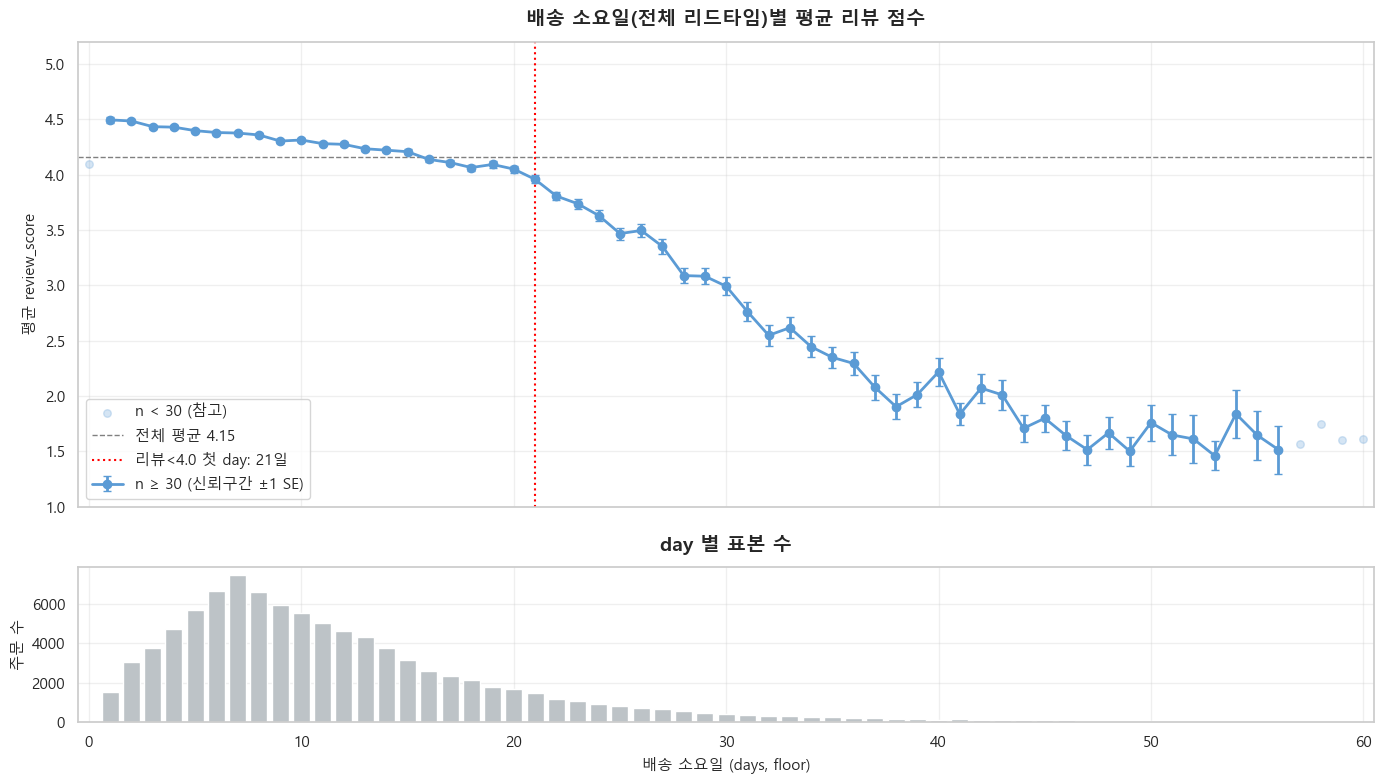

In [3]:
# x축은 0~60일까지만 (그 너머는 너무 sparse)
X_MAX = 60
plot_df = review_total[review_total["day"] <= X_MAX].copy()
robust  = plot_df[plot_df["is_robust"]]
sparse  = plot_df[~plot_df["is_robust"]]

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True,
                         gridspec_kw={"height_ratios": [3, 1]})

# ── 상단: 평균 리뷰 ± 표준오차
axes[0].errorbar(robust["day"], robust["avg_review"], yerr=robust["se"],
                 fmt="o-", color=STAGE_COLORS["t_total_d"], lw=2, ms=6,
                 capsize=3, label=f"n ≥ 30 (신뢰구간 ±1 SE)")
axes[0].scatter(sparse["day"], sparse["avg_review"],
                color=STAGE_COLORS["t_total_d"], alpha=0.25, s=30,
                label="n < 30 (참고)")

# 전체 평균선
overall = data["review_score"].mean()
axes[0].axhline(overall, color="gray", ls="--", lw=1,
                label=f"전체 평균 {overall:.2f}")

# 변곡점 후보 표시 (평균 4.0 이하로 떨어지는 첫 day)
threshold = robust[robust["avg_review"] < 4.0]
if len(threshold):
    first_drop = threshold["day"].min()
    axes[0].axvline(first_drop, color="red", ls=":", lw=1.5,
                    label=f"리뷰<4.0 첫 day: {first_drop}일")

axes[0].set_ylabel("평균 review_score")
axes[0].set_title("배송 소요일(전체 리드타임)별 평균 리뷰 점수")
axes[0].set_ylim(1, 5.2)
axes[0].legend(loc="lower left")

# ── 하단: 표본 수 (참고용 막대)
axes[1].bar(plot_df["day"], plot_df["n"], color="#BDC3C7", width=0.8)
axes[1].set_xlabel("배송 소요일 (days, floor)")
axes[1].set_ylabel("주문 수")
axes[1].set_title("day 별 표본 수")
axes[1].set_xlim(-0.5, X_MAX + 0.5)

plt.tight_layout()
plt.show()


### 📌 시각화 ① 해석 포인트
- **하향 곡선**: 배송이 길어질수록 평균 리뷰가 떨어지는 우하향 패턴 — 가설 검증.
- **변곡점 (빨간 점선)**: 평균 리뷰가 4점 미만으로 처음 떨어지는 day → **이 시점부터 고객 만족도가 본격적으로 망가짐**.
- 표본 수 막대(하단): 대부분의 주문이 10일 이내에 도착 — 그 이후 day 의 평균은 **표본이 적어 변동 큼**.
- 오차막대(±1 SE): 짧으면 해당 평균이 신뢰할 만하다는 뜻. 긴 day로 갈수록 막대가 커짐.

## 3. 시각화 ② — 단계별 비교 (어느 단계가 만족도를 더 깎는가)

같은 그래프를 ② 판매자 구간(`t_carrier_d`) / ③ 택배사 구간(`t_delivery_d`) 에도 그려서 **단계별 만족도 영향력**을 비교한다.

같은 1일 차이여도 판매자 1일 늘어남 vs 택배사 1일 늘어남이 만족도에 미치는 영향이 다를 수 있음.

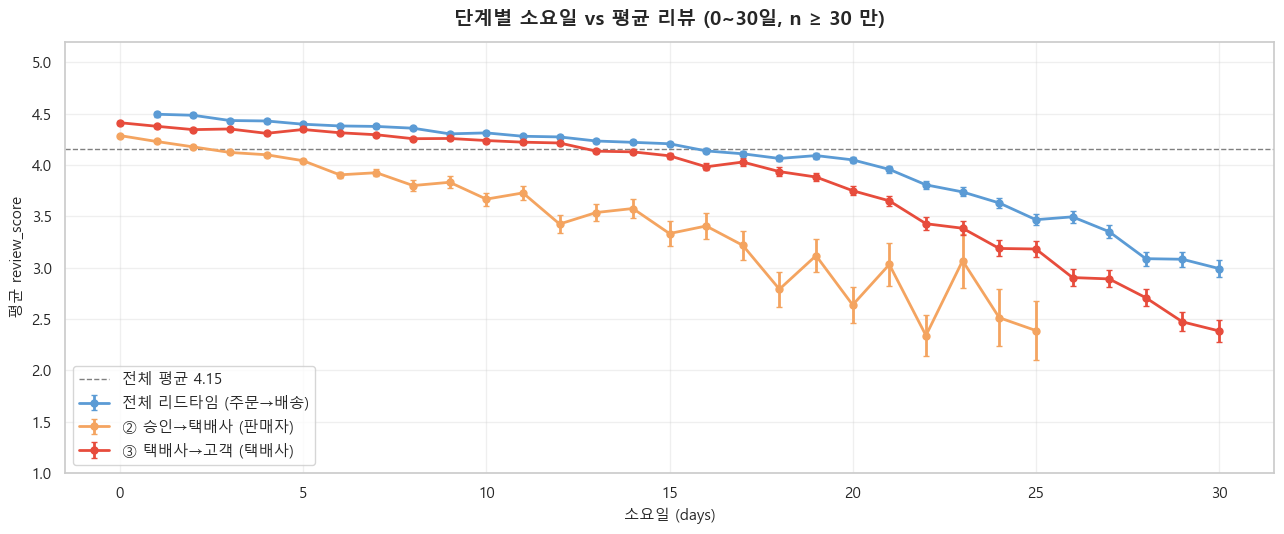

📊 단계별 1일당 평균 리뷰 감소량 (기울기):
  전체 리드타임 (주문→배송)          : -0.0474 / day
  ② 승인→택배사 (판매자)           : -0.0739 / day
  ③ 택배사→고객 (택배사)           : -0.0624 / day


In [4]:
# 세 단계 모두 집계
review_by_stage = {
    col: review_by_day(data, col + "_day")
    for col in ["t_total_d", "t_carrier_d", "t_delivery_d"]
}

X_MAX = 30   # 비교 구간을 짧게 잡아 단계별 기울기 비교가 잘 되게
fig, ax = plt.subplots(figsize=(13, 5.5))

for col, g in review_by_stage.items():
    sub = g[(g["day"] <= X_MAX) & (g["is_robust"])]
    ax.errorbar(sub["day"], sub["avg_review"], yerr=sub["se"],
                fmt="o-", color=STAGE_COLORS[col], lw=2, ms=5, capsize=2,
                label=STAGE_LABELS[col])

# 전체 평균 기준선
ax.axhline(overall, color="gray", ls="--", lw=1, label=f"전체 평균 {overall:.2f}")

ax.set_xlabel("소요일 (days)")
ax.set_ylabel("평균 review_score")
ax.set_title(f"단계별 소요일 vs 평균 리뷰 (0~{X_MAX}일, n ≥ 30 만)")
ax.set_ylim(1, 5.2)
ax.legend(loc="lower left")
plt.tight_layout()
plt.show()

# 단계별 "1일 늘어날 때 평균 리뷰 변화" — 선형회귀로 기울기 계산
print("📊 단계별 1일당 평균 리뷰 감소량 (기울기):")
for col, g in review_by_stage.items():
    sub = g[(g["day"] <= X_MAX) & (g["is_robust"])]
    if len(sub) >= 3:
        slope = np.polyfit(sub["day"], sub["avg_review"], 1)[0]
        print(f"  {STAGE_LABELS[col]:25s}: {slope:+.4f} / day")


### 📌 시각화 ② 해석 포인트
- **기울기가 가장 가파른 선** = 1일 늘어남이 만족도를 가장 많이 깎는 단계 → **개선 시 가장 임팩트 큰 구간**.
- 판매자 구간(주황)은 0~5일 구간에서 짧지만 변화가 클 수 있음 (대부분 주문이 짧은 구간에 몰려있음).
- 택배사 구간(빨강)은 길이가 길어 곡선이 더 길게 우하향.
- 전체(파랑)는 두 구간의 합성 효과.

## 4. 시각화 ③ — 평균 뒤에 숨은 분포 (히트맵 + 누적막대)

평균만 보면 "4.5점 → 3.5점" 정도로 보여도, 실제로는 **5점 비율이 줄고 1점 비율이 폭증**해서 양극화될 수 있다.
평균이 다 말해주지 않는 부분을 점수(1~5) 분포로 확인.

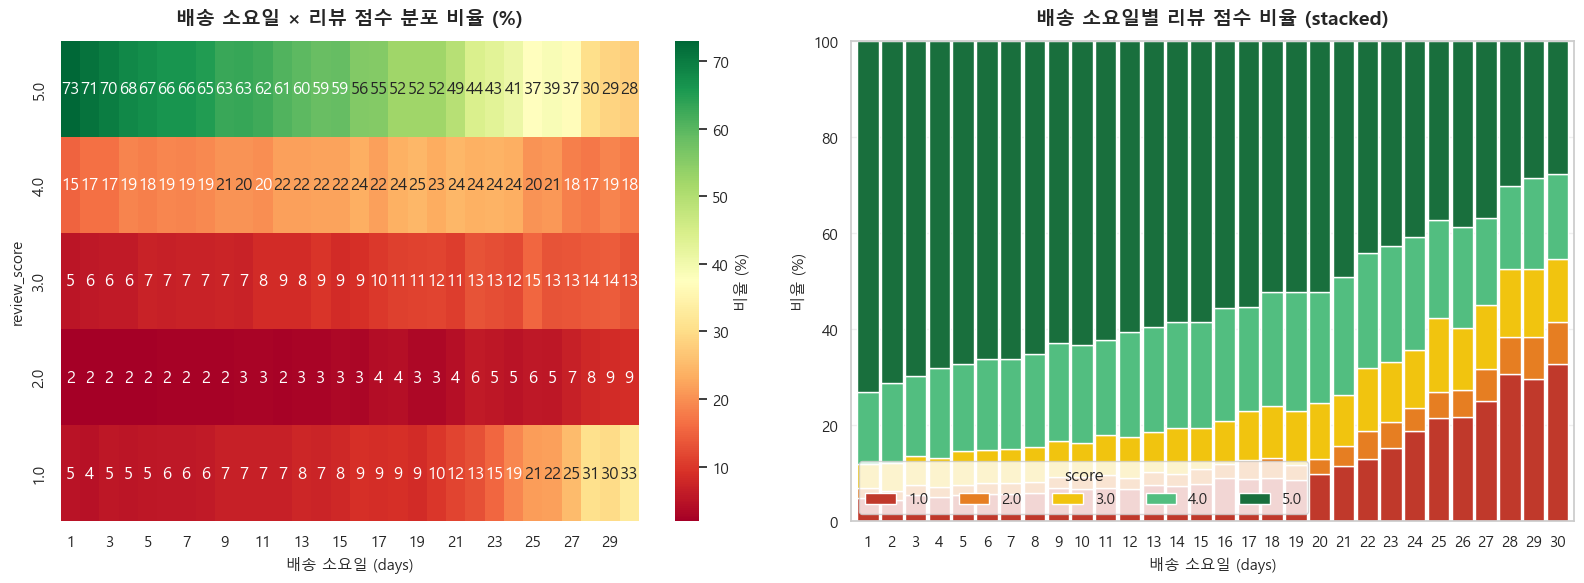

배송일별 5점/1점 비율 (앞 10일):
               5점 비율(%)  1점 비율(%)
t_total_d_day                    
1                  73.0       4.8
2                  71.3       4.5
3                  69.9       5.5
4                  68.2       5.1
5                  67.2       5.5
6                  66.3       5.7
7                  66.2       5.6
8                  65.2       5.8
9                  62.9       6.9
10                 63.3       6.6


In [5]:
# 표본이 충분한 day 만 사용 (n >= 30), x축은 0~30일
X_MAX = 30
robust_days = review_total[(review_total["day"] <= X_MAX) & (review_total["is_robust"])]["day"]
subset = data[data["t_total_d_day"].isin(robust_days)]

# day × review_score 카운트 → 행별로 비율로 정규화
dist = (
    subset.groupby(["t_total_d_day", "review_score"])
          .size().unstack(fill_value=0)
)
dist_pct = dist.div(dist.sum(axis=1), axis=0) * 100   # 행 비율(%)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# (1) 히트맵 — day × score 비율
sns.heatmap(dist_pct.T, annot=True, fmt=".0f", cmap="RdYlGn",
            cbar_kws={"label": "비율 (%)"}, ax=axes[0])
axes[0].set_title("배송 소요일 × 리뷰 점수 분포 비율 (%)")
axes[0].set_xlabel("배송 소요일 (days)")
axes[0].set_ylabel("review_score")
axes[0].invert_yaxis()   # 5점이 위로 가게

# (2) 누적 막대 — 점수별 색상으로 day 별 비율
score_colors = {1: "#C0392B", 2: "#E67E22", 3: "#F1C40F", 4: "#52BE80", 5: "#196F3D"}
dist_pct.plot(kind="bar", stacked=True, ax=axes[1],
              color=[score_colors[s] for s in dist_pct.columns], width=0.9)
axes[1].set_title("배송 소요일별 리뷰 점수 비율 (stacked)")
axes[1].set_xlabel("배송 소요일 (days)")
axes[1].set_ylabel("비율 (%)")
axes[1].legend(title="score", loc="lower left", ncol=5)
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)
axes[1].set_ylim(0, 100)

plt.tight_layout()
plt.show()

# 양극화 정량화: 5점 비율 vs 1점 비율 (배송일별)
polar = pd.DataFrame({
    "5점 비율(%)": dist_pct[5.0] if 5.0 in dist_pct.columns else dist_pct[5],
    "1점 비율(%)": dist_pct[1.0] if 1.0 in dist_pct.columns else dist_pct[1],
}).round(1)
print("배송일별 5점/1점 비율 (앞 10일):")
print(polar.head(10))


### 📌 시각화 ③ 해석 포인트
- **히트맵 색상 변화**: 짧은 day(왼쪽) 에서는 위쪽(5점)이 진한 초록 → 오른쪽(긴 day)으로 가면 아래쪽(1점)이 진한 빨강.
- **누적 막대 모양 변화**: 짧은 day = 초록 비중 > 빨강 비중 / 긴 day = 빨강 비중 ↑.
- **5점 비율 감소 속도 vs 1점 비율 증가 속도**: 어느 쪽이 더 가파른지가 "고객이 점수를 깎는 방식"을 말함.
  - 5점이 빠르게 줄지만 1점은 천천히 늘면 → 만족 고객이 "그냥 그저 그런" 으로 바뀜.
  - 1점이 폭증하면 → 분노 리뷰 발생, **CS 비용·환불 위험 ↑** 영역.

## 5. 결과 저장

각 day별 평균 리뷰 표를 csv로 저장해 발표 자료에서 그대로 인용할 수 있게 한다.

In [6]:
# 세 단계 결과를 한 파일로 합쳐 저장
out = (
    pd.concat({
        "t_total_d":    review_by_stage["t_total_d"],
        "t_carrier_d":  review_by_stage["t_carrier_d"],
        "t_delivery_d": review_by_stage["t_delivery_d"],
    }, names=["stage"])
    .reset_index(level=0)
    .reset_index(drop=True)
)
out.to_csv("review_avg_per_day.csv", index=False)
print("저장: review_avg_per_day.csv")
print(f"행수: {len(out):,}")
print()
print(out.head(10).round(3))


저장: review_avg_per_day.csv
행수: 338

       stage  day  avg_review     n    std     se  is_robust
0  t_total_d    0       4.091    11  1.300  0.392      False
1  t_total_d    1       4.493  1512  1.027  0.026       True
2  t_total_d    2       4.483  3044  1.008  0.018       True
3  t_total_d    3       4.432  3735  1.072  0.018       True
4  t_total_d    4       4.428  4694  1.049  0.015       True
5  t_total_d    5       4.396  5657  1.078  0.014       True
6  t_total_d    6       4.379  6622  1.091  0.013       True
7  t_total_d    7       4.375  7468  1.093  0.013       True
8  t_total_d    8       4.357  6608  1.103  0.014       True
9  t_total_d    9       4.302  5909  1.150  0.015       True


---

# 🎯 종합 정리

## 무엇을 계산했나
배송에 N일 걸린 주문 그룹의 **평균 리뷰 점수**를, 세 가지 단위로 계산:

| 분석 단위 | 의미 |
|---|---|
| `t_total_d` | 주문→배송 완료 (전체 리드타임) — **메인 지표** |
| `t_carrier_d` | 결제 승인→택배사 인도 (판매자 단계) |
| `t_delivery_d` | 택배사 인도→고객 배송 (택배사 단계) |

## 어떻게 계산했나
1. **데이터 필터**: `is_valid_funnel == True` AND `review_score` 존재 (≈ 94k건).
2. **버킷팅**: `np.floor` 로 정수 일수 그룹화 (예: 2.7일 → 2일 버킷).
3. **집계**: 그룹별 `review_score` 의 평균/표본수/표준오차.
4. **노이즈 제거**: n < 30 인 day는 통계적으로 불안정 → 그래프에서 흐리게 표시.
5. **임계점 탐지**: 평균 리뷰가 4.0 미만으로 처음 떨어지는 day 를 변곡점으로 마킹.

## 시각화 3종 요약
| # | 시각화 | 답하는 질문 |
|---|---|---|
| ① | day vs 평균 리뷰 (errorbar + 표본수) | "리뷰가 언제부터 망가지나?" — **변곡점** |
| ② | 세 단계 동시 비교 (3 line) | "어느 단계 1일이 만족도를 가장 깎나?" — **개선 우선순위** |
| ③ | day × score 비율 히트맵 + 누적막대 | "평균 뒤에 숨은 양극화는?" — **1점 비율 폭증 구간** |

## 산출물
- `review_avg_per_day.csv` — 세 단계의 day별 (avg_review, n, std, se) 표

## A/B 테스트 KPI 정의에 줄 수 있는 인사이트
1. **임계 배송일 = 평균 리뷰가 4.0 아래로 처음 떨어지는 day** → A/B 테스트의 성공 기준 (예: "X일 이내 배송 비율을 Y% → Z% 로").
2. **단계별 기울기** → 어느 단계 1일 단축이 만족도를 더 많이 회복시키는지 → **개선 우선순위**.
3. **양극화 구간** → CS 비용·환불 위험까지 고려한 비용 추정에 활용.

## 주의
- 평균 리뷰는 **표본 수가 적으면 변동성이 큼**. 그래프의 흐린 점·긴 오차막대 구간은 의사결정 근거로 직접 쓰지 말 것.
- 인과관계가 아님 — "배송이 길어서 리뷰가 낮다" 외에 **상품 품질, 가격, 판매자 평판** 등 교란 요인 가능. 결론을 낼 때는 **상관성**으로 표현.
- 평균만 보지 말고 **분포(시각화 ③)도 같이 보고 판단**.